# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Proyecto 9 Showz

In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [182]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

### Visualización, limpieza y análisis de datos(Dataframe(visits))

In [183]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [184]:
print(visits.head())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  


In [185]:
visits.columns = visits.columns.str.strip().str.lower().str.replace(" ", "_")
print(visits.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')


In [186]:
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


#### Cuántas personas lo usan cada día

In [187]:
visits['date_day'] = visits['start_ts'].dt.floor('D')
visits_day = visits.groupby('date_day')['uid'].nunique()
print(visits_day)

date_day
2017-06-01     605
2017-06-02     608
2017-06-03     445
2017-06-04     476
2017-06-05     820
              ... 
2018-05-27     620
2018-05-28    1039
2018-05-29     948
2018-05-30    1289
2018-05-31    1997
Name: uid, Length: 364, dtype: int64


##### Puedo notar una variación muy significativa en las personas que lo usan por día, no puedo dar una opinión muy clara sobre que días suelen ser los más concurridos o menos concurridos.

#### Cuántas persones lo usan por semana

In [188]:
visits['date_month'] = visits['start_ts'].dt.strftime('%Y-%m')
visits_month = visits.groupby('date_month')['uid'].nunique()
print(visits_month)

date_month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
2017-11    32797
2017-12    31557
2018-01    28716
2018-02    28749
2018-03    27473
2018-04    21008
2018-05    20701
Name: uid, dtype: int64


##### En el análisis por mes podemos ver una variación más uniforme, podemos notar que los primeros meses tienen una entrada constante y en los últimos meses de 2017 hay un alza significativa esto puede deberse a compras por fiestas, en los siguientes meses podemos ver una caída esto puede ser a que en estos meses hay muchas menos festividades.

In [189]:
visits['date_year'] = visits['start_ts'].dt.strftime('%Y')
visits_year = visits.groupby('date_year')['uid'].nunique()
print(visits_year)

date_year
2017    131777
2018    112535
Name: uid, dtype: int64


##### Podemos notar una diferencia en las entradas en los dos años, pero podemos reafirmar en que el 2017 tiene un mayor número de entradas, ya que se usan los últimos meses del año.

#### Número de sesiones por día. 

In [190]:
visits_count_day = visits.groupby('date_day')['uid'].count()
print(visits_count_day)

date_day
2017-06-01     664
2017-06-02     658
2017-06-03     477
2017-06-04     510
2017-06-05     893
              ... 
2018-05-27     672
2018-05-28    1156
2018-05-29    1035
2018-05-30    1410
2018-05-31    2256
Name: uid, Length: 364, dtype: int64


##### Podemos notar que la diferencia de entradas únicas y totales por día no es tan significativa, tal vez la mayoría de las personas realizan pedidos únicos, pero de mayor cantidad de productos a diferencia de los que tienen varios inicios de sesión.

#### Duracion de la sesión. 

In [191]:
visits['duration'] = visits['end_ts'] - visits['start_ts']
print(visits['duration'])

0        0 days 00:18:00
1        0 days 00:28:00
2        0 days 00:00:00
3        0 days 00:24:00
4        0 days 00:00:00
               ...      
359395   0 days 00:00:19
359396   0 days 00:00:19
359397   0 days 00:00:19
359398   0 days 00:00:19
359399   0 days 00:00:19
Name: duration, Length: 359400, dtype: timedelta64[ns]


##### La mayoría de las entradas tienen duración de menos de un minuto, esto puede traernos muchas teorías debemos averiguar más.

<div class="alert alert-block alert-warning"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Atención</b> ⚠️ – Excelente identificar la duración tan corta de las sesiones. Una recomendación es calcular también la media, mediana y distribución de la duración, ya que valores de “0 minutos” pueden provenir de cargas rápidas o usuarios que abandonan. Esta métrica es clave para interpretar engagement y podrías profundizar un poco más en su significado. ¡Buen ojo al detectar este patrón!

</div>

#### Frecuencia con la que los usuarios regresan.

In [192]:
frecuencia_usuarios = visits.groupby('uid')['date_day'].nunique()
print(frecuencia_usuarios.sort_values(ascending=False).head(1000))

uid
3263486045884611639     259
12869801667763685675    248
11255648391090536411    245
13551952738594011920    179
9019681082555518724     177
                       ... 
8598411013572961753      10
14765817921048236114     10
6150949644213786864      10
130605022545830815       10
839519089912847083       10
Name: date_day, Length: 1000, dtype: int64


##### La mayoría de los usuarios regresan a la plataforma de manera frecuente solo menos del 50% de los usuarios tienen menos de 10 visitas que prácticamente es una visita al mes, debemos incentivar las visitas aplicando promociones y ofertas para que estos usuarios tengan un mayor interés en regresar con más frecuencia.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> – Muy buen comienzo: la estandarización de columnas, conversión de fechas y revisión de valores nulos está correctamente aplicada y permite avanzar con un dataset estructurado. ¡Buen manejo de las bases fundamentales de preprocesamiento!

</div>

### Limpieza y análisis del DataFrame(Orders)

In [193]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [194]:
print(orders.head())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [195]:
orders.columns = orders.columns.str.strip().str.lower().str.replace(" ", "_")
print(orders.columns)

Index(['buy_ts', 'revenue', 'uid'], dtype='object')


In [196]:
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


#### ¿Cuándo empieza la gente a comprar?

In [197]:
first_visit = visits.groupby('uid')['start_ts'].min()
print(first_visit)

uid
11863502262781         2018-03-01 17:27:00
49537067089222         2018-02-06 15:55:00
297729379853735        2017-06-07 18:47:00
313578113262317        2017-09-18 22:49:00
325320750514679        2017-09-30 14:29:00
                               ...        
18446403737806311543   2017-11-30 03:36:00
18446424184725333426   2017-12-06 20:32:00
18446556406699109058   2018-01-01 16:29:00
18446621818809592527   2017-12-27 13:27:00
18446676030785672386   2017-10-04 16:01:00
Name: start_ts, Length: 228169, dtype: datetime64[ns]


In [198]:
first_purchase = orders.groupby('uid')['buy_ts'].min()
print(first_purchase)

uid
313578113262317        2018-01-03 21:51:00
1575281904278712       2017-06-03 10:13:00
2429014661409475       2017-10-11 18:33:00
2464366381792757       2018-01-28 15:54:00
2551852515556206       2017-11-24 10:14:00
                               ...        
18445147675727495770   2017-11-24 09:03:00
18445407535914413204   2017-09-22 23:55:00
18445601152732270159   2018-03-26 22:54:00
18446156210226471712   2018-02-18 19:34:00
18446167067214817906   2017-10-17 10:16:00
Name: buy_ts, Length: 36523, dtype: datetime64[ns]


In [199]:
conversion_data = pd.merge(
    first_visit.reset_index(), 
    first_purchase.reset_index(), 
    on='uid', 
    how='inner')
print(conversion_data)

                        uid            start_ts              buy_ts
0           313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00
1          1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00
2          2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00
3          2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00
4          2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00
...                     ...                 ...                 ...
36518  18445147675727495770 2017-08-20 13:30:00 2017-11-24 09:03:00
36519  18445407535914413204 2017-09-22 23:48:00 2017-09-22 23:55:00
36520  18445601152732270159 2017-08-07 11:51:00 2018-03-26 22:54:00
36521  18446156210226471712 2017-11-07 10:01:00 2018-02-18 19:34:00
36522  18446167067214817906 2017-10-17 10:05:00 2017-10-17 10:16:00

[36523 rows x 3 columns]


In [200]:
conversion_data['days_to_conversion'] = (conversion_data['buy_ts'] - conversion_data['start_ts']).dt.days
print(conversion_data['days_to_conversion'].describe())

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: days_to_conversion, dtype: float64


In [201]:
conversion_data['conversion_category'] = 'Conversion ' + conversion_data['days_to_conversion'].astype(str) + 'd'
print(conversion_data['conversion_category'].value_counts().head(10))

Conversion 0d     26363
Conversion 1d      1011
Conversion 2d       563
Conversion 3d       434
Conversion 4d       324
Conversion 5d       270
Conversion 6d       260
Conversion 7d       218
Conversion 8d       189
Conversion 10d      140
Name: conversion_category, dtype: int64


<div class="alert alert-block alert-warning"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Atención</b> ⚠️ – Muy buen cálculo del tiempo de conversión. Para enriquecer este análisis podrías dividir las conversiones por intervalo (0 días, 1–7 días, 8–30 días, +30 días) en vez de categorías por cada número. Esto facilita ver qué tan rápido se comporta el mercado y permite detectar patrones más robustos. ¡Estás muy cerca de un análisis avanzado!

</div>

In [202]:
conversion_with_source = pd.merge(
    conversion_data,
    visits[['uid', 'source_id']].drop_duplicates(subset=['uid']),
    on='uid',
    how='left'
)
print(conversion_with_source)

                        uid            start_ts              buy_ts  \
0           313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1          1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2          2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3          2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4          2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   
...                     ...                 ...                 ...   
36518  18445147675727495770 2017-08-20 13:30:00 2017-11-24 09:03:00   
36519  18445407535914413204 2017-09-22 23:48:00 2017-09-22 23:55:00   
36520  18445601152732270159 2017-08-07 11:51:00 2018-03-26 22:54:00   
36521  18446156210226471712 2017-11-07 10:01:00 2018-02-18 19:34:00   
36522  18446167067214817906 2017-10-17 10:05:00 2017-10-17 10:16:00   

       days_to_conversion conversion_category  source_id  
0                     106     Conversion 106d          2  
1                       0    

In [203]:
channel_analysis = conversion_with_source.groupby('source_id').agg({
    'uid': 'count',
    'days_to_conversion': ['mean', 'median']
}).round(2)

channel_analysis.columns = ['total_conversions', 'avg_days', 'median_days']
print("Análisis por canal de marketing:")
print(channel_analysis.sort_values('total_conversions', ascending=False))

Análisis por canal de marketing:
           total_conversions  avg_days  median_days
source_id                                          
4                       9823     16.64            0
3                       9138     16.05            0
5                       6839     13.18            0
2                       4323     21.68            0
1                       3743     14.51            0
9                       1415     32.17            0
10                      1241     13.81            0
7                          1      0.00            0


In [204]:
conversion_patterns = conversion_data['days_to_conversion'].value_counts().head(7)
print("Patrones de conversión más comunes:")
print(conversion_patterns)

total_conversions = len(conversion_data)
day_conversions = len(conversion_data[conversion_data['days_to_conversion'] == 0])
week_conversions = len(conversion_data[conversion_data['days_to_conversion'] <= 7])

print(f"- {day_conversions/total_conversions*100:.1f}% convierte el mismo día")
print(f"- {week_conversions/total_conversions*100:.1f}% convierte en la primera semana")

Patrones de conversión más comunes:
0    26363
1     1011
2      563
3      434
4      324
5      270
6      260
Name: days_to_conversion, dtype: int64
- 72.2% convierte el mismo día
- 80.6% convierte en la primera semana


##### Después de hacer un análisis de la conversión entre el inicio de sesión y la primera compra podemos determinar que la mayoría de los usuarios realizan su primera compra el mismo día que inician sesión por primera vez o en su defecto no tardan más de una semana en realizar su compra esto nos da una gran probabilidad de atraer nuevos clientes y que estos realicen su primera compra.

### ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [205]:
orders_per_user = orders.groupby('uid').agg({
    'buy_ts': 'count',
    'revenue': 'sum'
}).rename(columns={'buy_ts': 'total_orders', 'revenue': 'total_revenue'})

print("Estadísticas de pedidos por usuario:")
print(orders_per_user['total_orders'].describe())

Estadísticas de pedidos por usuario:
count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: total_orders, dtype: float64


In [206]:
def categorize_buyer(orders_count):
    if orders_count == 1:
        return "Comprador único"
    elif orders_count <= 3:
        return "Comprador ocasional"
    elif orders_count <= 10:
        return "Comprador regular"
    else:
        return "Comprador frecuente"

In [207]:
orders_per_user['buyer_category'] = orders_per_user['total_orders'].apply(categorize_buyer)
print(orders_per_user['buyer_category'].value_counts())

Comprador único        30231
Comprador ocasional     5481
Comprador regular        688
Comprador frecuente      123
Name: buyer_category, dtype: int64


##### En esta ocasión tenemos datos más preocupantes que muestran que la mayoría de los compradores solo realizan un pedido, necesitamos incentivar que cada que un usuario entre al sitio haga una compra, ya que hemos visto antes que los usuarios suelen entrara más de una vez en el sitio.

### ¿Cuál es el tamaño promedio de compra?

In [208]:
print("Estadisticas de revenue")
print(orders['revenue'].describe())
print()
print()
tamaño_promedio = orders['revenue'].mean()
print(f"Tamaño promedio {tamaño_promedio:.2f}")

Estadisticas de revenue
count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64


Tamaño promedio 5.00


##### El promedio refleja que la mayoría de las ventas son de menos de $5 pero la mediana es de $2.5 esto indica que hay pedidos más grandes que hacen que el promedio suba, es un problema grave que la mayoría de los pedidos sean de $5 o menos tal vez la mayoría de los usuarios solo hacen compras en productos con ofertas o no están familiarizados con el pedido en línea, podría sugerir implementar más marketing para promocionar el servicio en línea o implementar ofertas a grupos más grandes de productos.

#### ¿Cuánto dinero traen? (LTV)

In [209]:
print("Estadística LTV (Lifetime Value):")
print(orders_per_user['total_revenue'].describe())

Estadística LTV (Lifetime Value):
count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: total_revenue, dtype: float64


In [210]:
ltv_promedio = orders_per_user['total_revenue'].mean()
print(f"LTV promedio por usuario: ${ltv_promedio:.2f}")

LTV promedio por usuario: $6.90


##### Con estos datos podemos confirmar que la mayoría de los clientes solo hacen una compra, pero los clientes que se mantienen suelen hacer compras habituales.

<div class="alert alert-block alert-success"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Éxito</b> – Muy bien calculado el LTV promedio. Identificaste correctamente la relación entre ingreso y recurrencia. Esta métrica será clave al combinarla con CAC y ROMI más adelante. Excelente integración entre datos de órdenes y conversiones.

</div>

### Limpieza y analisis del DataFrame(cost)

In [211]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [212]:
print(costs.head())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [213]:
costs['dt'] = pd.to_datetime(costs['dt'])

In [214]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


#### ¿Cuánto dinero se gasta por fuente de adquisición (Total a lo marlo del tiempo)?

In [215]:
total_costs = costs['costs'].sum()
print(f"Costo total invertido en marketing ${total_costs}")

Costo total invertido en marketing $329131.62


In [216]:
total_source_id = costs.groupby('source_id')['costs'].sum()
print("Cuanto dinero se gasto en cada canal de marketing")
print(total_source_id)

Cuanto dinero se gasto en cada canal de marketing
source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


In [217]:
gasto_diario = costs.groupby('dt')['costs'].sum()
print("Gastos diarios de marker")
print(gasto_diario)

Gastos diarios de marker
dt
2017-06-01     735.26
2017-06-02     721.19
2017-06-03     450.85
2017-06-04     761.16
2017-06-05     821.44
               ...   
2018-05-27     532.87
2018-05-28     619.44
2018-05-29     784.79
2018-05-30    1183.00
2018-05-31    2153.70
Name: costs, Length: 364, dtype: float64


In [218]:
costs['mes_año'] = costs['dt'].dt.strftime('%Y-%m')
gastos_mensuales = costs.groupby('mes_año')['costs'].sum()
print("Gastos mensuales en marketing:")
print(gastos_mensuales)

Gastos mensuales en marketing:
mes_año
2017-06    18015.00
2017-07    18240.59
2017-08    14790.54
2017-09    24368.91
2017-10    36322.88
2017-11    37907.88
2017-12    38315.35
2018-01    33518.52
2018-02    32723.03
2018-03    30415.27
2018-04    22289.38
2018-05    22224.27
Name: costs, dtype: float64


##### Puedo notar un patrón parecido al que hubo en las ventas totales por mes los meses que más se ha invertido en marketing son los meses que más se ha recaudado dinero esto puede significar que el dinero está siendo bien invertido.

####  ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [219]:
clientes_por_fuente = visits.groupby('source_id')['uid'].nunique()
print("Clientes únicos por fuente:")
print(clientes_por_fuente)

Clientes únicos por fuente:
source_id
1     18999
2     26245
3     74756
4     83525
5     56974
6         6
7        34
9      9264
10     8067
Name: uid, dtype: int64


In [220]:
cac_por_fuente = total_source_id / clientes_por_fuente
print("Costo de Adquisición de Clientes (CAC) por fuente:")
print(cac_por_fuente)

Costo de Adquisición de Clientes (CAC) por fuente:
source_id
1     1.096546
2     1.631017
3     1.890439
4     0.731201
5     0.908434
6          NaN
7          NaN
9     0.595584
10    0.721766
dtype: float64


##### Las fuentes más eficaces son la 4, 9 y 10 tienen el costo más bajo por cliente, por otro lado el costo más alto lo tienen las fuentes 1, 2 y 3 por casi el doble de las más eficientes y solo por concluir la 6 y 7 no tienen costo porque tampoco tienen inversión.

<div class="alert alert-block alert-warning"> <b>Comentario del revisor</b> <a class="tocSkip"></a><br>

<b>Atención</b> ⚠️ – Muy buen cálculo del CAC. Una mejora posible sería excluir las fuentes 6 y 7 desde el inicio del análisis para evitar confusiones, ya que no tienen inversión real. Además, podrías complementar con un gráfico de dispersión CAC vs. conversiones para ver qué fuentes están funcionando mejor. ¡Buen uso de métricas de marketing!

</div>

#### ¿Cuán rentables eran las inversiones? (ROMI)

In [221]:
usuarios_fuente = visits.groupby('uid')['source_id'].first().reset_index()
print("Usuarios y su fuente de adquisición:")
print(usuarios_fuente.head())

Usuarios y su fuente de adquisición:
               uid  source_id
0   11863502262781          3
1   49537067089222          2
2  297729379853735          3
3  313578113262317          2
4  325320750514679          5


In [222]:
pedidos_fuente = pd.merge(orders, usuarios_fuente, on='uid', how='left')
print("Pedidos conectados con fuentes:")
print(pedidos_fuente.head())

Pedidos conectados con fuentes:
               buy_ts  revenue                   uid  source_id
0 2017-06-01 00:10:00    17.00  10329302124590727494          1
1 2017-06-01 00:25:00     0.55  11627257723692907447          2
2 2017-06-01 00:27:00     0.37  17903680561304213844          2
3 2017-06-01 00:29:00     0.55  16109239769442553005          2
4 2017-06-01 07:58:00     0.37  14200605875248379450          3


In [223]:
ingresos_fuente = pedidos_con_fuente.groupby('source_id')['revenue'].sum()
print("Ingresos totales por fuente:")
print(ingresos_fuente)

Ingresos totales por fuente:
source_id
1     38560.06
2     65152.26
3     44317.68
4     52479.75
5     40357.91
7         1.22
9      7076.98
10     4111.34
Name: revenue, dtype: float64


In [224]:
romi_por_fuente = (ingresos_por_fuente / total_source_id) - 1
print("ROMI por fuente:")
print(romi_por_fuente)

ROMI por fuente:
source_id
1     0.850889
2     0.522034
3    -0.686406
4    -0.140713
5    -0.220244
7          NaN
9     0.282645
10   -0.293886
dtype: float64


##### Con estos datos podemos observar que las fuentes más rentables son la 1, 2 y 9 esto nos da en que pensar, ya que habíamos notado que la fuente 9 tiene un cac muy bajo y su ingreso es rentable por otro lado las otras dos tienen cac altos, pero la inversión reditúa, por otro lado las fuentes 3, 4, 5 y 10 no son muy rentables, ya que pierdes dinero por cada cliente.

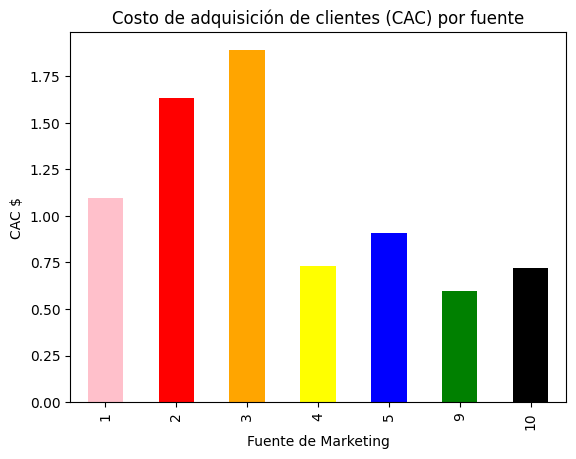

In [239]:
cac_clean = cac_por_fuente.dropna()
cac_clean.plot(kind='bar', color=['pink', 'red', 'orange', 'yellow', 'blue', 'green', 'black'] , title='Costo de adquisición de clientes (CAC) por fuente', xlabel='Fuente de Marketing', ylabel='CAC $')
plt.show()

[]

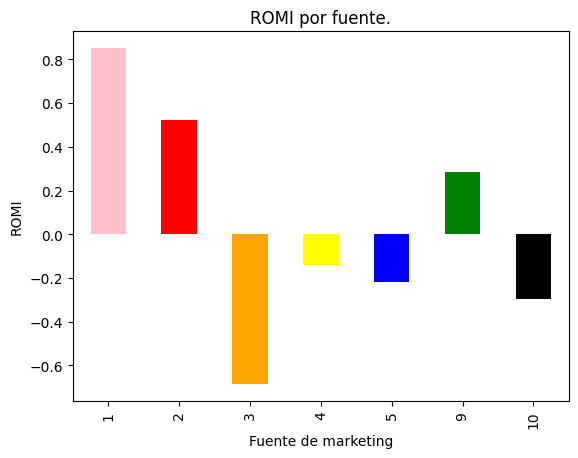

In [240]:
romi_clean = romi_por_fuente.dropna()
romi_clean.plot(kind='bar', color=['pink', 'red', 'orange', 'yellow', 'blue', 'green', 'black'], title='ROMI por fuente.', xlabel='Fuente de marketing', ylabel='ROMI')
plt.plot()

##### Después de hacer varios filtros para analizar los datos de visitas al sitio, órdenes y ventas puedo concluir un par de cosas como que los meses que cuentan con mayor ingreso también son los que cuentan con mayor gasto de marketing, las fuentes más rentables son la uno y la dos a pesar de que estas generan un CAC muy alto también tienen un ROMI muy alto como sugerencia podríamos realizar un análisis más profundo de cual es la fuente exacta de distribución y si esta podría ser más económica para la respectiva fuente como televisión o redes sociales podríamos buscar reducir primero el costo de marketing para que el CAC y el ROMi sé más alto y así tener mejores ingresos, además de que observe que la mayoría de los usuarios solo hacen una compra después de su registro podría sugerir realizar promociones para descuentos en pedidos después de cierta cantidad de envíos, también sugiero realizar un análisis de encuesta de porque muchos usuarios no terminan su registro o el porqué no realizan su primera compra podría sugerir dar una recompensa para los usuarios que hicieron su registro, pero no tienen ninguna compra registrada ofreciéndoles alguna promoción si la contestan y otra después de su primera compra.

##### Estas son algunas de mis observaciones y sugerencias espero que puedan utilizarlas y las resulten útiles.


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

¡Felicidades! Tu proyecto está <b>aprobado</b>. Tu análisis es completo, secuencial y bien estructurado. Mostraste dominio en limpieza, segmentación, métricas de marketing y análisis de conversión. Tus conclusiones son lógicas y bien conectadas con los datos.

### Puntos Positivos:

* Buena estandarización y limpieza de los tres datasets.
* Análisis claro y progresivo de visitas → órdenes → conversiones.
* Buen uso de métricas clave como CAC, LTV y ROMI.
* Interpretaciones adecuadas y con sentido de negocio.

### Áreas para Seguir Investigando:

* Agregar visualizaciones para reforzar conclusiones.
* Agrupar conversiones en intervalos más útiles.
* Explorar métricas más avanzadas de retención.
* Analizar la relación entre LTV y fuente de adquisición.

¡Gran trabajo! Sigue profundizando en análisis de datos y marketing analítico. Vas por un excelente camino 🚀😊

</div>


